<a href="https://colab.research.google.com/github/atsuro0415/GCI/blob/main/GCI2026S_%E7%AC%AC9%E5%9B%9E__%E6%95%99%E5%B8%AB%E3%81%AA%E3%81%97%E5%AD%A6%E7%BF%92_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第 9 回: 機械学習の基礎 (教師なし学習)

**本講義回での目標**

**教師なし学習の種類と概要を学び, Python を用いてモデルの構築や評価を正しく実行できるようになる.**

第 9 回では, 教師なし学習について学びます.
教師なし学習は, 目的変数 (正解ラベル) のないデータから, その背後にある構造やパターンを見つけ出すアプローチです.

本章では 'クラスタリング' と '次元削減' について学びます.
この章を通し, 教師なし学習の多様な活用イメージと実行方法を理解しましょう.

> **[注意事項]**
>
> 本資料ではタイトルに '(発展)' と書いてある章が存在します.
> GCI では, 該当の章を完全に理解しなくても修了できる設計となっているため, 時間に限りにある方は該当の章以外を優先的に学習するようにしましょう.

---

## 1. 教師なし学習

**キーワード: クラスタリング, 次元削減**

教師なし学習は, 目的変数 (正解ラベル) のないデータから, その背後にある構造やパターンを見つけ出すアプローチです.
機械学習におけるより良いモデル構築のため, 教師あり学習と併用されたり探索的データ分析 (EDA.) の段階でデータに潜む構造や示唆を発見するための手法として活用されています.

本章を通し, 教師なし学習の多様な活用イメージと実行方法を理解しましょう。

### 1.1. 教師なし学習の種類

教師なし学習には主に次のようなものがあります.

- **クラスタリング**
  - 多数のデータをいくつかの類似したグループに分類する手法
  - 膨大なデータの中にどのようなグループが存在するかを見つけられる
  - 'このグループにはこのような傾向がある' と理解しやすくできる

- **次元削減**
  - 変数が多い場合に類似する変数同士を統合する手法
  - 本質的ではないノイズを除去してデータの本質を抽出できる
  - データを軽量化することでその後の処理を高速化できる

'クラスタリング' と '次元削減' について, その特徴を比較することでイメージを掴みましょう.

| 項目 \ 手法 | クラスタリング | 次元削減 |
| :--- | :--- | :--- |
| 目的 | データをグループ化する | 変数を統合して新たな変数とする |
| 結果 | グループ A, B, C, ... | 第 1, 2, 3, ... 主成分 |
| イメージ | 本をジャンル別に棚分けする | 分厚い本を要約して短くする |

### 1.2. Python における教師なし学習

Python において, 教師なし学習は `scikit-learn` で実装することができます. 以下のセルを実行して, 2 章以降の実装に備えましょう.

※ 本 Jupyter Notebook の実行は Google Colaboratory 環境を想定しているため, 異なる環境を用いる方は適宜修正してください

In [1]:
# 環境構築
!git clone -q https://github.com/mahhie393/visualiser 2>/dev/null || git -C visualiser pull -q
!command -v pip >/dev/null 2>&1 && pip install -q scikit-learn matplotlib seaborn pandas numpy scipy

# アルゴリズム
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# データセット
from sklearn.datasets import load_iris, load_digits

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns
import visualiser

# 構造化
import pandas as pd

# 型ヒント
from numpy import ndarray, int64
from matplotlib.axes import Axes

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. クラスタリング

**キーワード: クラスタリング, k 平均法, k-means, k-means++, k-medoids, シルエット係数**

クラスタリングとは多数のデータをいくつかのグループ (クラスター) に分類する手法のことで, 膨大なデータの中にどのようなグループが存在するかを見つけられることができます.
実際に機械学習の現場では, 分析者自身が取り扱うデータの特徴を把握するための初期分析の 1 つとして採用されることがあります.

本講義回ではクラスタリング手法の 1 つである 'k 平均法 (k-means clustering)' について学びます.

### 2.1. k 平均法の概要

クラスタリングにはデータをグループに分割する際, その '答え' が存在しないという特徴があります.
また, 人間が手動で 1 つ 1 つ分類するのと異なり, プログラミングでは何かしらのアルゴリズムに基づいて一括で分類するため, その手法は慎重に選ばれる必要があります.

さまざま存在するクラスタリング手法の中で, 代表的とされる手法が k 平均法です.
一般的には以下のステップで実装されます.

1. 分析者がデータをいくつのクラスターに分割したいか ($k$) を指定する
2. 全データから暫定的な各クラスターの中心点としてランダムに $k$ 個選択する
3. 全データを最も近い各クラスターの中心点の属するクラスターに割り当てる
4. 各クラスターに割り当てられたデータの重心を計算し, 中心点を移動させる
5. `3.` と `4.` の手順を収束するまで繰り返す

デモを通じて, そのイメージを理解しましょう.

In [3]:
demo = visualiser.KMeans()
demo.show()

### 2.2. k 平均法の実践

scikit-learn で k 平均法を実行するには `sklearn.cluster.KMeans` クラスを使います.
今回は `sklearn.dataset.load_iris()` によって取得できる, Iris データセットを用いて k 平均法の 1 つである k-means を体験してみましょう.

In [4]:
X, y = load_iris(return_X_y = True)

Iris データセットには萼片の長さと幅, 花弁の長さと幅で 4 次元のデータが存在しているため, 今回は花弁の長さと幅のみで k 平均法を適用してみることにします.

In [5]:
X = X[:, 2:4]

`matplotlib` (`seaborn`) を使って可視化してみましょう.

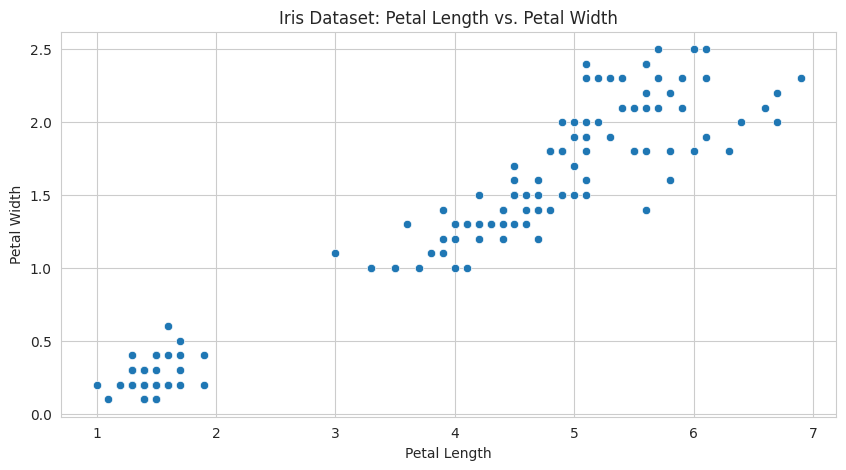

In [10]:
iris = pd.DataFrame({
    'Petal Length' : X[:, 0],
    'Petal Width' : X[:, 1]
})

plt.figure(figsize = (10, 5))
sns.set_style('whitegrid')
sns.scatterplot(data = iris, x = 'Petal Length', y = 'Petal Width')
plt.title('Iris Dataset: Petal Length vs. Petal Width')
plt.show()

k 平均法を行う前に, データに対して標準化 (Z-Score 正規化) を行います.
今回は `scikit-learn` より `sklearn.preprocessing.StandardScaler` クラスを用います.

In [6]:
scaler = StandardScaler()#標準化
X_scaled = scaler.fit_transform(X)

Iris データセットではラベルが 3 種類用意されていることが知られているため, それに倣う形で k-means を適用し, データを 3 クラスターに分類してみます.
k 平均法は乱数を用いているため, 再現性のために `random_state = 42` を指定します.

<kbd>**乱数の再現性**</kbd>

> 機械学習のアルゴリズム内で乱数を使うことがよくあります.
> 実は Python における乱数は完全にランダムというわけではなく, あるアルゴリズムによって生成された疑似乱数である場合がほとんどです.
> そのため seed と呼ばれる値 (ここでは `random_state` に相当する値) を指定することで, その乱数の生成方法を固定化することができます.
>
> どのアルゴリズムにおいても必ずこの値が指定できるとは限りませんが, 一般的に後から分析結果を見る人のために seed が指定できる際は指定することが推奨されます.
>
> (一般的に seed の値として `42` が選択されることが多く, 諸説はありますが, Douglas Adams の著作 'The Hitchhiler's Guide to the Galaxy' に由来するとされています)

In [7]:
model = KMeans(n_clusters = 3, init = 'random', random_state = 42)
result = model.fit_predict(X_scaled)

適用結果を先ほどと同様に可視化してみましょう.
せっかくなので, 各クラスターの重心 (centroid) も表示することにします.

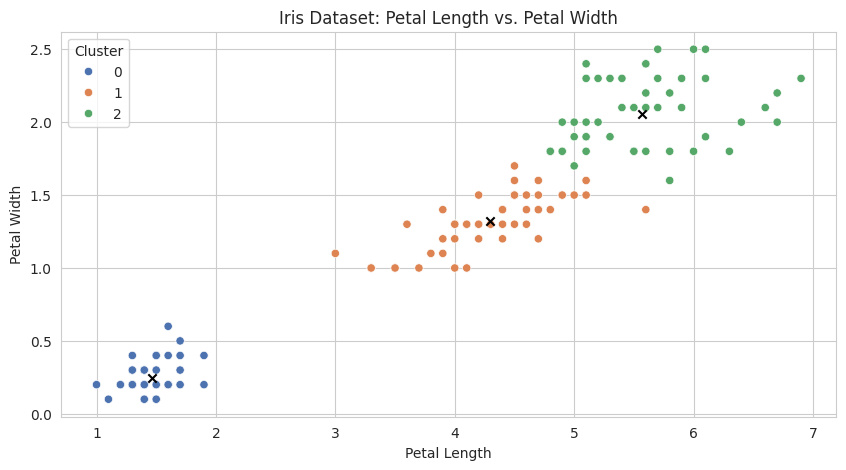

In [11]:
iris['Cluster'] = result
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize = (10, 5))
sns.set_style('whitegrid')
sns.scatterplot(data = iris, x = 'Petal Length', y = 'Petal Width', hue = 'Cluster', palette = 'deep')
plt.scatter(centroids[:, 0], centroids[:, 1], c = 'black', marker = 'x')
plt.title('Iris Dataset: Petal Length vs. Petal Width')
plt.show()

k-means によって Iris データセットが 3 分割されたことが確認できます.

各クラスターを最頻の品種に対応付けて, どれくらい正確に判別できたか確認してみましょう.

In [ ]:
mapping = {column : np.bincount(y[result == column]).argmax() for column in np.unique(result)}
aligned : ndarray = np.array([mapping[column] for column in result])

print(f'ラベルとの一致率: {(y == aligned).mean():.2%}')

ラベルとの一致率: 96.00%


### 2.3. (発展) k 平均法における中心点の初期化

`2.2.` では k-means を用いましたが, `scikit-learn` でのデフォルトは 'k-means++' となっています.
k-means と k-means++ の違いは各クラスターの中心点を初期化する際の処理にあります.

1. データの中から最初の中心点 $c_1$ をランダムに 1 つ選ぶ.
2. 次の中心点 $c_2$ を選ぶ際, 既に選ばれた中心点から距離が遠いデータほど選ばれやすくなるように確率計算を行う
3. `2.` を $k$ 個選ぶまで繰り返す

k-means と比べて k-means++ は初期化に時間がかかりますが, それ以降の処理においてその収束は高速化される傾向にあります.

`sklearn.cluster.KMeans` では, 引数で `init = 'k-means++'` を指定することで k-means++ を使えるようになります.

他にも中心点を平均値ではなく中央値とする 'k-medoids' も存在します.
k-medoids では k-means や k-means++ とは異なり, 実際に存在する点を中心点とするため, 外れ値などの影響を抑えることができます.

### 2.4. (発展) k 平均法における数学的な 'k' の最適解

さて, ここまで k 平均法の概要とその実装について触れてきましたが, 始めに私たちが指定しなくてはならない $k$ はどのようにして決めるのが最適でしょうか.
データの分布によっては $k$ の値が適切でないために, k 平均法の恩恵を最大限享受できない可能性もあります.

ここでは指定した $k$ が適切かを評価する指標の 1 つである 'シルエット係数 (Silhouette Coefficient)' を挙げたいと思います.
各データ $i$ に対する, シルエット係数 $s(i)$ の計算式は以下の通りです.

$$
s(i) = \frac{b(i) - a(i)}{\max (a(i), b(i))}
$$

**構成要素**

- $a(i)$: 凝集度 (intra-cluster distance)
  
  つまりはクラスター内距離のことで, データ $i$ と同じクラスターに属する他の点との平均距離を指す.

- $b(i)$: 分離度 (nearest-cluster distance)

  つまりは隣接クラスター間距離のことで, データ $i$ と異なるクラスターのうち, 最も近いクラスターとの平均距離を指す.

シルエット係数は, 以上の計算により -1 から 1 の範囲で算出され, 1 に近いほど適切に分類されていると評価することができます.
`scikit-learn` では `sklearn.metrics.silhouette_score()` として実装されています.

<kbd>**現実的な 'k' の最適解**</kbd>

> 例えば, 顧客のセグメンテーションに k 平均法を用いて $k = 10$ が数学的に '最適' であった場合, 私たちは 10 個のクラスターに対してそれぞれ異なる施策を打ち出すべきでしょうか.
>
> それは確かに理想的ではあるのかもしれませんが, 実際はコストパフォーマンスの面で上手くいかないかもしれません.
>
> 実際にビジネスなどの場で k 平均法を課題解決に繋げるとき, 実は $k$ が数学的に '最適' であっても, 現実的には '最適' でない可能性は念頭に置いておきましょう.

## 3. 次元削減

**キーワード: 次元削減, 主成分分析, PCA, t-SNE**

次元削減とは変数が多い場合に類似する変数同士を統合する手法のことで, 本質的ではないノイズを除去してデータの本質を抽出することができます.
実際に機械学習の現場では, 分析者自身がモデルの精度や効率を向上させるための初期実装の 1 つとして採用されることがあります.

本講義回では次元削減手法の 1 つである '主成分分析 (PCA; Principal Component Analysis)' について学びます.

### 3.1. 主成分分析の概要

さまざま存在する次元削減手法の中で, 代表的とされる手法が主成分分析です.
一般的には以下のステップで実装されます.

1. 分析者がどの変数を削減したいか指定する
2. 指定された変数を標準化する (平均値を 0, 分散を 1 となるように変換する)
3. 分散共分散行列を算出する
4. 固有値とそれに対応する固有ベクトルを算出し, 対応する固有値が大きい順に並び替える
5. 選択した主成分 (固有ベクトル) を用いて指定された変数を新しい座標系へ投影する

つまり, ある変数においてその分散が大きいほどその変数によって表現される範囲が広いという性質を利用して, なるべく情報損失が小さくなるように次元を削減していると言い換えることができます.

新たにクラスターを以て変数を与えるクラスタリングと異なり次元削減は既存の変数を消してしまう操作なので, 実際に用いる場合は慎重な判断が求められます.

| 項目 \ 判定 | 主成分分析を使うべき | 他の手法を検討すべき |
| :--- | :--- | :--- |
| 相関 | 類似した変数が複数ある | 各変数が独立して必要である |
| 形状 | データの分布が線形的である | データの分布が非線形的である |
| 目的 | ノイズを除去して効率化したい | 特定の変数の影響を知りたい |

### 3.2. 主成分分析の実践

scikit-learn で主成分分析を実行するには `sklearn.decomposition.PCA` クラスを使います.
今回は `sklearn.dataset.load_digits()` によって取得できる Digit データセットを用いて主成分分析を体験してみましょう.

In [12]:
X, y = load_digits(return_X_y = True)

Digit データセットは 8 x 8 の手書き文字の画像から構成されています.

テーブルとして見るか画像として見るかによって, 我々の認識の仕方は異なりますが, 画像データであっても 1 つ 1 つの画素が数値に紐づいているため, Digit データセットはこれまでと同様に変数が 64 個あるデータの集合と考えることができます.

せっかくなので, その様子を確認するために `matplotlib` を用いて, Digit データセットの最初の 10 個を可視化してみましょう.

In [13]:
rows, columns = 2, 5
number = rows * columns

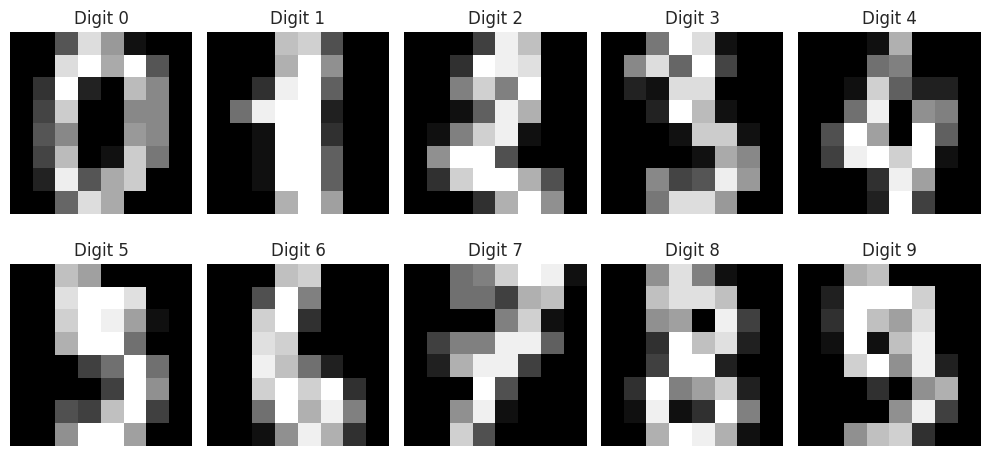

In [14]:
images, labels = X[:number], y[:number]

_, axes = plt.subplots(rows, columns, figsize = (10, 5), squeeze = False)

for i in range(number):

    axis : Axes = axes[i // columns][i % columns]
    image : ndarray = images[i]
    label : int64 = labels[i]

    axis.imshow(image.reshape(8, 8), cmap = 'gray')
    axis.set_axis_off()
    axis.set_title(f'Digit {label}')

plt.tight_layout()
plt.gray()
plt.show()

主成分分析を行う前に, データに対して標準化 (Z-Score 正規化) を行います.
今回も `scikit-learn` より `sklearn.preprocessing.StandardScaler` クラスを用います.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

それでは主成分分析を適用して, データを 2 次元に削減してみます.

In [16]:
model = PCA(n_components = 2)
X_pca = model.fit_transform(X_scaled)

適用結果を先ほどと同様に可視化してみましょう.

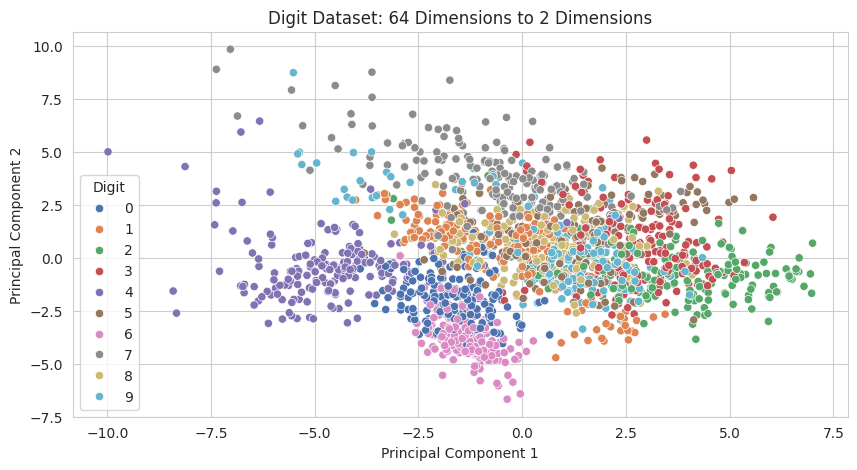

In [17]:
digit = pd.DataFrame({
    'Principal Component 1' : X_pca[:, 0],
    'Principal Component 2' : X_pca[:, 1],
    'Digit' : y
})

plt.figure(figsize = (10, 5))
sns.set_style('whitegrid')
sns.scatterplot(data = digit, x = 'Principal Component 1', y = 'Principal Component 2', hue = 'Digit', palette = 'deep')
plt.title('Digit Dataset: 64 Dimensions to 2 Dimensions')
plt.show()

主成分分析によって 64 次元の Digit データセットが 2 次元空間に投影されたことが確認できます.

さて, 64 次元から 2 次元に変換することで, どれだけの情報が保持できているのでしょうか.
確認してみましょう.

In [18]:
ratios = model.explained_variance_ratio_

print(f'第 1, 2 主成分の合計寄与率: {sum(ratios):.2%}')

第 1, 2 主成分の合計寄与率: 21.59%


以上から, 約 21.6 % ほどの情報が保持できていることがわかります.

実際に可視化したグラフを確認してみると, 0 (青), 4 (紫), 6 (桃) などは 2 次元空間に投影された状態でも, 比較的はっきりと独立したまとまりを形成していることがわかります.
一方で, 中央付近ではいくつかの数字が重なっており, 約 21.6 % という情報量では, 数字の微妙な相違が完全に区別しきれていないことがわかります.

実活用の際には, `sklearn.decomposition.PCA` クラスの引数として `n_components = x` $(0 \le x \le 1)$ を指定することで累積寄与率が $x$ を超える最小次元数を自動で計算されるため, この機能が使われることもしばしばあります.

### 3.3. (発展) 非線形な分布を持つデータに対する次元削減

さて, ここまで主成分分析の概要とその実装について触れてきましたが, 本手法の弱点として非線形な分布を持つデータに対しては適さないという点がありました.
この場合はどのような手法を用いるのが良いのでしょうか.

ここでは主成分分析とは異なる次元削減の手法の 1 つである 't-SNE (t-Distributed Stochastic Neighbour Embedding)' を挙げたいと思います. データに対する, t-SNE. の目的関数 $\hat{X}$ は以下の通りです.

$$
\hat{X} = \arg \min_{X} C(X) = \arg \min_{x} \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}(X)}
$$

**構成要素**

- $p_{ij}$: 高次元空間における類似度
  
  データ $i$, $j$ が元の高次元空間でどれだけ '近傍' に存在するかを示す確率分布を指す.

- $q_{ij}(X)$: 低次元空間における類似度

  データ $i$, $j$ が探索中の低次元空間でどれだけ '近傍' に存在するかを示す確率分布を指す.

つまりは, 高次元空間での確率分布と低次元空間での確率分布の類似度を最大化しているということになります.
(この 2 つの確率分布の違いを 'カルバック・ライブラー情報量 (KL. Divergence; Kullback–Leibler Divergence)' と呼びます)

データ全体の分布を捉える代わりに, 各データの近傍に着目しているため, t-SNE. は非線形な分布のデータにも対応しているのです.
(詳細なアルゴリズムは複雑なので本資料では割愛しますが, 興味のある方はぜひ調べてみてください)

## 4. 実践

ここまで学んできた 'クラスタリング' と '次元削減' を用いて, 乳がんに関するデータで構成されている Breast Cancer データセットの解析に挑戦してみましょう.

まずは, 環境構築です.
これまでに定義してきた変数と重複した名前を用いるため, データの混同が起きないように `%reset` による変数の初期化を行ってから進めます.

In [19]:
# 初期化
%reset -f

# アルゴリズム
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# データセット
from sklearn.datasets import load_breast_cancer

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 構造化
import numpy as np
import pandas as pd

# 型ヒント
from numpy import ndarray
from matplotlib.axes import Axes

データセットを読み込んで, その概要を把握しましょう.
今回は引数として `as_frame` を指定し, `pandas.DataFrame` として取り込みます.

In [20]:
bunch = load_breast_cancer(as_frame = True)

data : pd.DataFrame = bunch['data']
target : pd.Series = bunch['target']

`pandas.DataFrame.head()`, `pandas.Series.head()` から説明変数と目的変数それぞれに対する最初の 5 行を見てみます.

In [21]:
data.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
target.head(5)

,target
0,0
1,0
2,0
3,0
4,0


Breast Cancer データセットは腫瘍の画像を解析することで得た形状やテクスチャに関する以下の 10 項目から構成されていることが知られています.

| 変数 | 定義 |
| :--- | :--- |
| radius | 中心から輪郭上の点までの長さの平均 |
| texture | 表面のざらつき |
| perimeter | 輪郭の長さ |
| area | 面積 |
| smoothness | 輪郭の滑らかさ |
| compactness | 輪郭のまとまり具合 |
| concavity | 輪郭の凹み具合 |
| concave points | 輪郭の凹んでいる部分の数 |
| symmetry | 形状の対称性 |
| fractal dimension | 輪郭の複雑さ |

各画像に映っている全ての細胞核に対してこれらの項目を算出し, 平均値 (mean ...), 標準誤差 (... error), 最大値 (worst ...) の 3 統計量からデータセット化しています.
また, 目的変数は 0 または 1 で構成され, それぞれ悪性と良性が対応します.

Breast Cancer データセットに対して, まずは '主成分分析' を行って 10 x 3 = 30 ある次元を削減してみましょう.

> Q1. Breast Cancer データセットにおける説明変数 (`data`) を標準化して `X_scaled` に格納してください.

In [23]:
scaler = StandardScaler() # WRITE ME
X_scaled = scaler.fit_transform(data) # WRITE ME

正しく標準化されている場合, その平均値は 0, 分散は 1 となっているはずです.
以下のセルを実行して, 正しく Q1. に回答できているか確認してみましょう.

In [24]:
print(all(np.isclose(X_scaled.mean(axis = 0), 0.)) and all(np.isclose(X_scaled.var(axis = 0), 1.)))

True


`True` が表示されていれば正答です.

> Q2. `X_scaled` に対して主成分分析を適用して `X_pca` に格納してください. ただし, 引数である `n_components` は指定してはいけません.

In [25]:
model_pca = PCA()# WRITE ME
X_pca = model_pca.fit_transform(X_scaled)# WRITE ME

ここでは累積寄与率を確認してみることにしましょう.
以下のセルを実行して, 可視化をします.

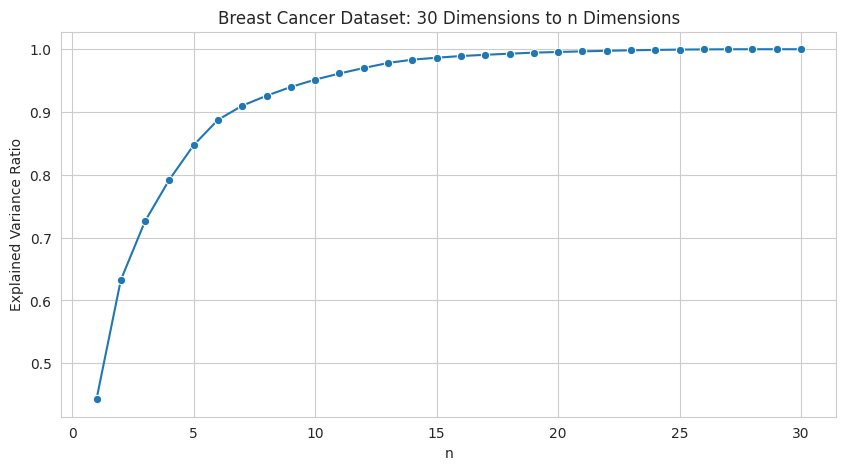

In [26]:
cumsum = pd.DataFrame({
    'n' : range(1, X_scaled.shape[1] + 1),
    'Explained Variance Ratio': np.cumsum(model_pca.explained_variance_ratio_)
})

plt.figure(figsize = (10, 5))
sns.set_style('whitegrid')
sns.lineplot(data = cumsum, x = 'n', y = 'Explained Variance Ratio', marker = 'o')
plt.title('Breast Cancer Dataset: 30 Dimensions to n Dimensions')
plt.show()

以上から Breast Cancer データセットは 7 変数のみでその 90 % 程度を表現できることがわかります.

今回は, 可視化のために 2 次元 に削減します.

In [27]:
X_pca = X_pca[:, :2]

さて, `X_pca` に対して k-means++ ($k = 2$) を適用して, 良性と悪性に分割できるか試してみましょう.

> Q3. `X_pca` に対して k-means++ を適用して `y_pred` に格納してください. `sklearn.cluster.KMeans` はデフォルトで k-means++ を利用するため, `init = 'k-means++'` の指定は問いません. ただし, 再現性を担保するために `random_state = 42` を指定してください.

In [28]:
model_kmeans = KMeans(n_clusters = 2, init = 'k-means++',random_state = 42)# WRITE ME
y_pred = model_kmeans.fit_predict(X_pca)# WRITE ME

最後に PCA. で削減した 2 次元空間に, k-means++ を適用した結果と真のラベルをそれぞれ描いて比較してみましょう.

次のセルでは複雑なフローを踏んでいますが, 具体的にしていることは以下の通りです.
本講義回においては全てを理解する必要はありませんが, Python に対する更なる知見を獲得するためにも, 時間に余裕のある方は何をしているか確認すると良いでしょう.

1. `pandas.DataFrame` にここまでの過程を集約させる
2. 可視化において, その境界線を示すために教師あり学習モデルの 1 つである `sklearn.linear_model.LogisticRegression` からラベルの境界を判定する (k-means++ によって算出されるクラスタの境界は既に `model_kmeans` が学習しています)
3. `numpy.linspace()` と `numpy.meshgrid()` を用いて点群を作成し, `model_lr` と `model_kmeans` を用いて境界上に変換する
4. `matplotlib` を活用して可視化を進める
5. k-means++ によって割り当てられる `y_pred` の値と `y_true` の値は必ずしも対応しているわけではないので `max()` を用いて判定する

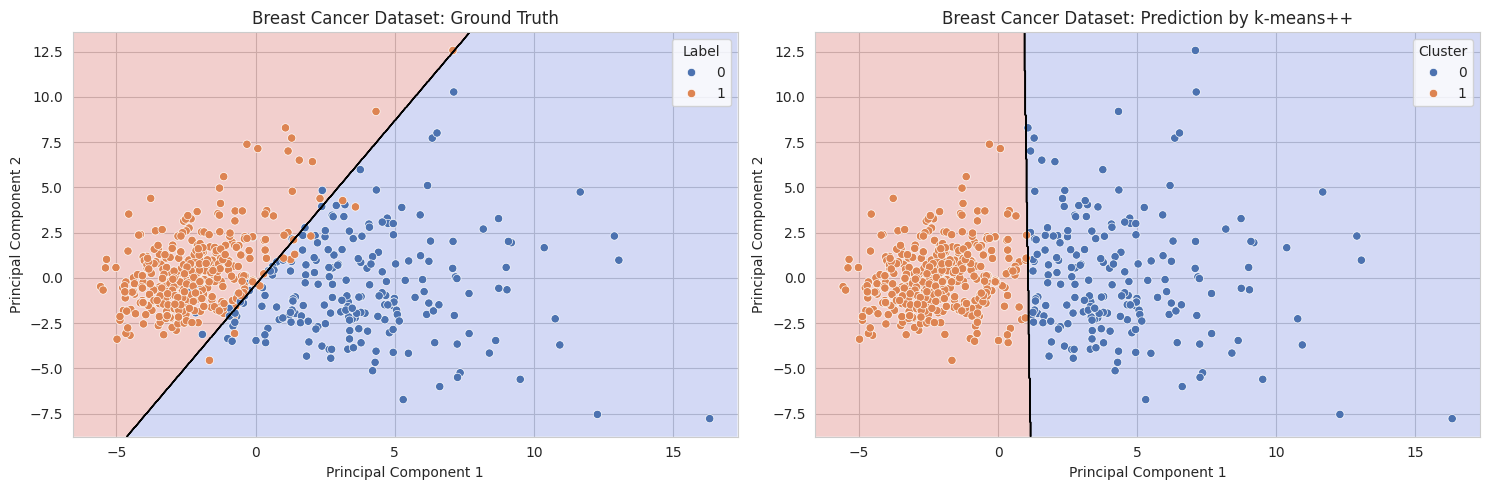

ラベルとの一致率: 90.69%


In [29]:
y_true : ndarray = target.values

#元のデータがどう二次元に削減できたか
result = pd.DataFrame({
    'Principal Component 1' : X_pca[:, 0],#1時限目
    'Principal Component 2' : X_pca[:, 1],#2時限目
    'Label': y_true,
    'Cluster': y_pred,
})

model_lr = LogisticRegression(random_state = 42)
model_lr.fit(X_pca, y_true)

x_min, x_max = result['Principal Component 1'].min() - 1, result['Principal Component 1'].max() + 1
y_min, y_max = result['Principal Component 2'].min() - 1, result['Principal Component 2'].max() + 1

x_grid, y_grid = map(np.array, np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000)))

zs = [
    model_lr.predict(np.column_stack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape),
    model_kmeans.predict(np.column_stack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
]

_, axes = plt.subplots(1, 2, figsize = (15, 5))
sns.set_style('whitegrid')

for i in range(2):

    axis : Axes = axes[i]
    z = zs[i]

    axis.contourf(x_grid, y_grid, z, alpha = 0.25, cmap = 'coolwarm', antialiased = True)
    axis.contour(x_grid, y_grid, z, linewidths = 0.75, colors = 'k', antialiased = True)

    sns.scatterplot(data = result, x = 'Principal Component 1', y = 'Principal Component 2', hue = f'{'Label' if not i else 'Cluster'}', palette = 'deep', ax = axis)

    axis.set_title(f'Breast Cancer Dataset: {'Ground Truth' if not i else 'Prediction by k-means++'}')

plt.tight_layout()
plt.show()

accuracy = max(np.mean((y_true == y_pred)), np.mean((y_true != y_pred)))

print(f'ラベルとの一致率: {accuracy:.2%}')

#k-means++ を用いればある程度未知分類。は可能であるという事実。
#この境界線。上ではやはりその曖昧な値というのはうまく分割できていない。


上記の図は左側で Breast Cancer データセットの真値を, 右側で k-means++ によって算出された分類結果を示しています.
実際に Breast Cancer データセットの真値は斜めに分布していますが, k-means++ の算出結果は主に第 1 主成分の値を基に 2 分割していることがわかります.

さて, 散布図の軸となった 2 軸は元の変数をどう合成したものなのでしょうか.
主成分は元の各変数に重み (負荷量; loadings) を掛けて足し合わせた合成変数です.
第 1 主成分の負荷量を可視化して, それが何を示す軸なのかを読み解いてみましょう.

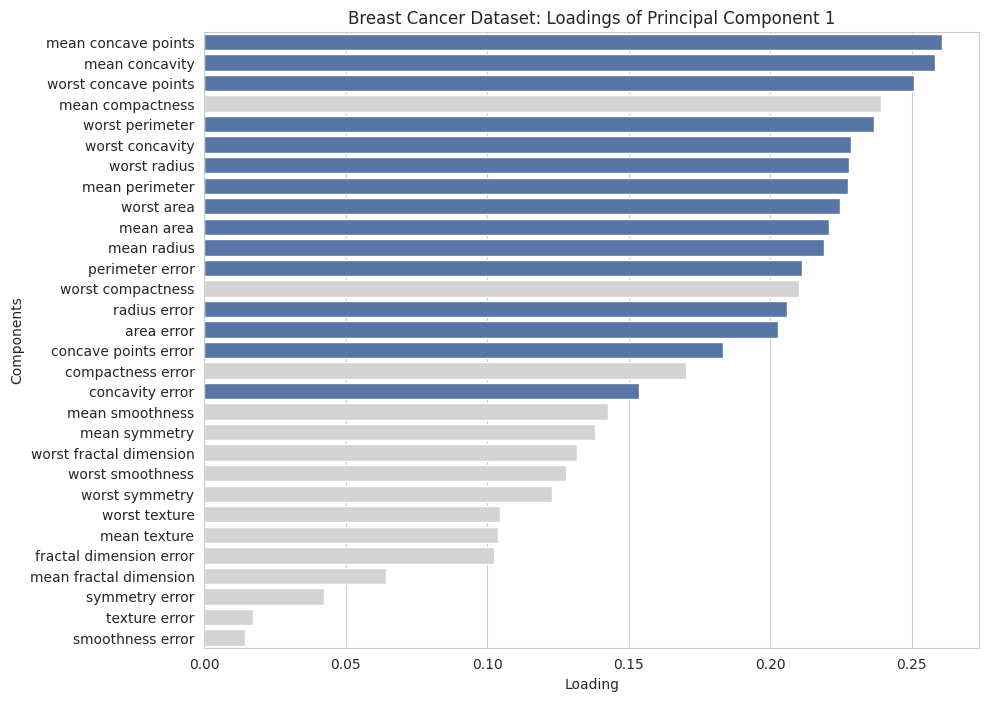

In [30]:
loadings = pd.Series(model_pca.components_[0], index = data.columns).sort_values(ascending = False)
keywords = ('concave', 'concavity', 'perimeter', 'radius', 'area')
palette = {name: (sns.color_palette('deep')[0] if any(key in name for key in keywords) else '#D3D3D3') for name in loadings.index}

plt.figure(figsize = (10, 8))
sns.set_style('whitegrid')

sns.barplot(x = loadings.values, y = loadings.index, palette = palette, hue = loadings.index, legend = False)

plt.title('Breast Cancer Dataset: Loadings of Principal Component 1')
plt.xlabel('Loading')
plt.ylabel('Components')

plt.show()

#第一主成分の構成要素が何かを表した図がこれ
#30次元あったデータを二次元に落とすだけでも一応解釈可能な結果は得られる場合があるというのが教師なし学習の特徴です



グラフを見ると, 第 1 主成分の負荷量に対して特に寄与が大きいのは concavity (凹み), perimeter (輪郭長), radius (半径), area (面積) などで, これらは '腫瘍が大きく輪郭が複雑である' ことを示す変数群です.

つまり, 第 1 主成分は個々の変数の単なる足し合わせというより '腫瘍の大きさや形状の深刻さ' をまとめて表す総合スコアとして解釈することができます.
講義スライドで '身長' と '体重' から '体格' という軸が現れた例と同じ構図が, 30 変数のデータでも起きているのです.

このように, 削減後の主成分を解釈可能な名前で言い換えられると,
'第 1 主成分が大きい個体ほど悪性の疑いが強い' のように, 次元削減の結果を意思決定へ繋げられるようになります.

---

### References

All datasets are accessed via `sklearn.datasets` as part of the scikit-learn built-in sample datasets, and are licensed under [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/).

| Dataset | Reference |
| :--- | :--- |
| **Iris Dataset** | Fisher, R. (1936). Iris [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56C76. |
| **Digit Dataset** | Alpaydin, E. & Kaynak, C. (1998). Optical Recognition of Handwritten Digits [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C50P49. |
| **Breast Cancer Dataset** | Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B. |